In [1]:
import tensorflow as tf
from tensorflow import keras
import os
import pandas as pd
from tensorflow.keras.applications import ResNet50V2
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imageio

In [2]:
baseline2 = keras.models.load_model('models/baseline2PR.h5')
baseline2.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 256, 256, 3)       0         
                                                                 
 resnet50v2 (Functional)     (None, 8, 8, 2048)        23564800  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 1)                 2049      
                                                                 
Total params: 23,566,849
Trainable params: 2,049
Non-trainable params: 23,564,800
_____________________________________________

In [3]:
TRAIN_PATH = 'datasets/ISIC_2020_corrected/train_resized'
train_images = os.listdir(TRAIN_PATH)
img = Image.open(f'{TRAIN_PATH}/{train_images[0]}')
img.size


(256, 256)

In [ ]:
num = 0
for img in range(1000):
    image = imageio.v2.imread(f'{TRAIN_PATH}/{train_images[img]}')
    image = np.expand_dims(image, axis=0)
    pred = baseline2(image)
    if pred > 0.5:
        num += 1
        print(f'{num}, {pred}')


In [ ]:
image = imageio.v2.imread(f'{TRAIN_PATH}/{train_images[0]}')
image = np.expand_dims(image, axis=0)
baseline2(image).numpy()[0][0]

In [4]:
PATH = 'datasets/ISIC_2020_corrected'
test = pd.read_csv(f'{PATH}/test_split.csv')
BATCH_SIZE = 64
AUTO = tf.data.experimental.AUTOTUNE

def decode(name, label):
    img = tf.io.read_file(name)
    img = tf.image.decode_jpeg(img, channels = 3)
    img = tf.cast(img, tf.float32)
    return img, label
    
def load_ds(df):
    options = tf.data.Options()
    options.experimental_deterministic = False
    imgs, labels = df["image_name"].values, df["target"].values
    imgs = [f'{PATH}/train_resized/{name}.jpg' for name in imgs]
    ds = tf.data.Dataset.from_tensor_slices((imgs, labels))
    ds = ds.with_options(options)
    ds = ds.map(decode, num_parallel_calls=AUTO)
    ds = ds.cache()
    ds = ds.shuffle(2048)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTO)
    return ds
test_ds = load_ds(test)
baseline2.evaluate(test_ds)

78/78 [==============================] - 19s 147ms/step - loss: 0.0732 - auc: 0.1000 - false_negatives: 87.0000 - true_positives: 0.0000e+00


[0.07321551442146301, 0.10000788420438766, 87.0, 0.0]

In [5]:
malignant = test.loc[test.index[test['target'] == 1]]
benign = test.loc[test.index[test['target'] == 0]]
malignant

,image_name,patient_id,lesion_id,sex,age_approx,anatom_site_general_challenge,diagnosis,benign_malignant,target
208,ISIC_6971606,IP_9375901,IL_9213093,female,25.0,torso,melanoma,malignant,1
221,ISIC_8724944,IP_3089004,IL_7415900,female,45.0,torso,melanoma,malignant,1
227,ISIC_1255336,IP_7650895,IL_3080866,female,65.0,lower extremity,melanoma,malignant,1
278,ISIC_3023646,IP_6658881,IL_3206915,male,80.0,head/neck,melanoma,malignant,1
312,ISIC_2320481,IP_9205637,IL_1645335,male,65.0,torso,melanoma,malignant,1
...,...,...,...,...,...,...,...,...,...
4536,ISIC_0914168,IP_3659172,IL_7413123,female,50.0,torso,melanoma,malignant,1
4577,ISIC_8866651,IP_8375879,IL_4249218,male,75.0,torso,melanoma,malignant,1
4583,ISIC_7960321,IP_4327880,IL_7205523,male,75.0,torso,melanoma,malignant,1
4632,ISIC_3697702,IP_2809878,IL_9287863,female,45.0,torso,melanoma,malignant,1


In [6]:
predictions = []
for name in list(malignant['image_name']):
    image = imageio.v2.imread(f'{TRAIN_PATH}/{name}.jpg')
    image = np.expand_dims(image, axis=0)
    predictions.append(baseline2(image).numpy()[0][0])


In [7]:
max(predictions), min(predictions), np.mean(predictions)

(0.47176817, 0.004276639, 0.07988645)

In [8]:
predictions_b = []
for name in list(benign['image_name']):
    image = imageio.v2.imread(f'{TRAIN_PATH}/{name}.jpg')
    image = np.expand_dims(image, axis=0)
    predictions_b.append(baseline2(image).numpy()[0][0])


In [9]:
max(predictions_b), min(predictions_b), np.mean(predictions_b)

(0.6622364, 0.00012771484, 0.018508948)

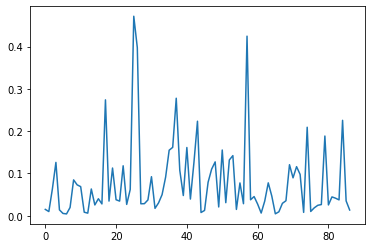

In [10]:
plt.plot(predictions)

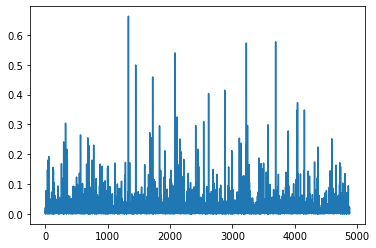

In [11]:
plt.plot(predictions_b)

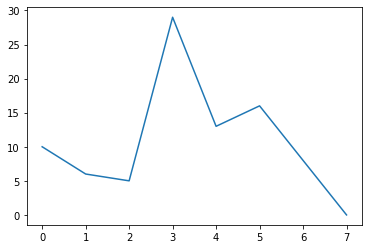

In [12]:
ranges = [(0.0, 0.01),(0.01, 0.015), (0.015, 0.025),(0.025, 0.05), (0.05, 0.1), (0.1, 0.2), (0.2, 0.5), (0.5, 1)]
groups = [0, 0, 0, 0, 0, 0, 0, 0]
for p in predictions:
    i = 0
    for r in ranges:
        if p > r[0] and p <= r[1]:
            groups[i] += 1
        i += 1
plt.plot(groups)

In [13]:
groups_b = [0, 0, 0, 0, 0, 0, 0, 0]
for p in predictions_b:
    i = 0
    for r in ranges:
        if p > r[0] and p <= r[1]:
            groups_b[i] += 1
        i += 1


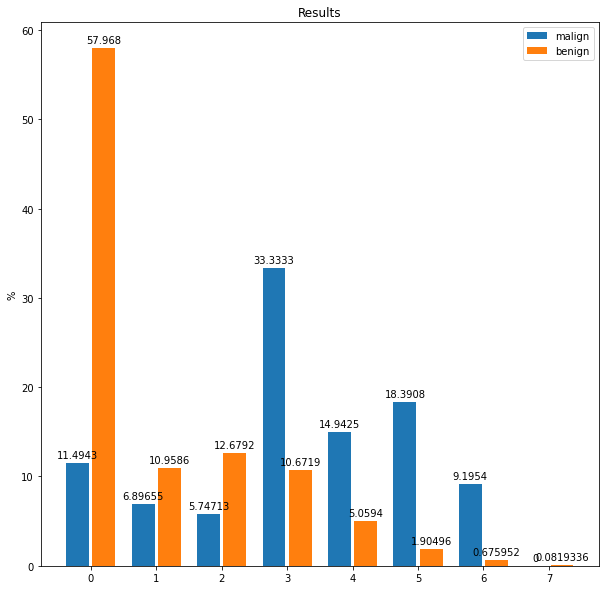

In [14]:
labels = ['0', '1', '2', '3', '4', '5', '6','7']
width=0.35
X_axis = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10,10))


b1 = plt.bar(x = X_axis-0.2, height=[g/len(predictions)*100 for g in groups],width = width, label='malign')
b2 = plt.bar(x = X_axis+0.2, height=[g/len(predictions_b)*100 for g in groups_b],width = width, label='benign')

ax.set_ylabel('%')
ax.set_title('Results')
ax.set_xticks(X_axis, labels)
ax.legend()

ax.bar_label(b1, padding=3)
ax.bar_label(b2, padding=3)

plt.show()

In [15]:
predictions_classes = []
for name in list(malignant['image_name']):
    image = imageio.v2.imread(f'{TRAIN_PATH}/{name}.jpg')
    image = np.expand_dims(image, axis=0)
    predictions.append(baseline2.predict_classes(image).numpy()[0][0])

AttributeError: 'Functional' object has no attribute 'predict_classes'